# Algunos datos de prueba para regresion (lineal y polinomial)

In [1]:
from math_core.regresion import lineal, polinomial

In [2]:
#funcion para evaluar un polinomio
def evaluar_pol(x, coefs):
    """
    Evaluacion de un polimio

    Args:
        x: los valores en donde evaluaremos el polinomio
        coefs: coeficientes del polinomio
    """
    # Sumamos cada coeficiente multiplicado por x elevado a su posición (índice)
    return sum(c * (x**i) for i, c in enumerate(coefs))

### Prueba 1: Regresion lineal

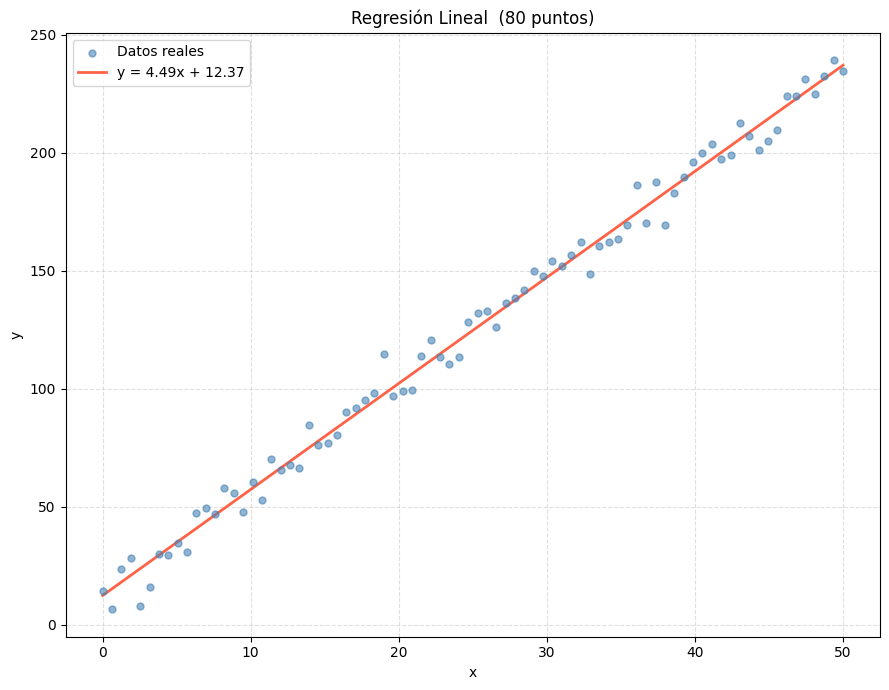

Real:      m=4.50,  b=12.00
Calculado: m=4.4933, b=12.3739


In [19]:
import numpy as np

# ══════════════════════════════════════════════════════
#  REGRESIÓN LINEAL  —  y = 4.5x + 12
# ══════════════════════════════════════════════════════
rng = np.random.default_rng(42)

x_lin = np.linspace(0, 50, 80)
ruido_lin = rng.normal(loc=0, scale=8, size=80)
y_lin = 4.5 * x_lin + 12 + ruido_lin

x_lin_lst = x_lin.tolist()
y_lin_lst = y_lin.tolist()

b, m = lineal.rls(x_lin_lst, y_lin_lst)

x_curva = np.linspace(min(x_lin), max(x_lin), 200).tolist()
y_curva = [evaluar_pol(xi, [b, m]) for xi in x_curva]

plt.figure(figsize=(9, 7))
plt.scatter(x_lin, y_lin, color="steelblue", s=25, alpha=0.6, zorder=5, label="Datos reales")
plt.plot(x_curva, y_curva, color="tomato", linewidth=2, label=f"y = {m:.2f}x + {b:.2f}")
plt.title("Regresión Lineal  (80 puntos)", fontsize=12)
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

print(f"Real:      m=4.50,  b=12.00")
print(f"Calculado: m={m:.4f}, b={b:.4f}")

## Prueba 2: Regresion polinomial (cubica)

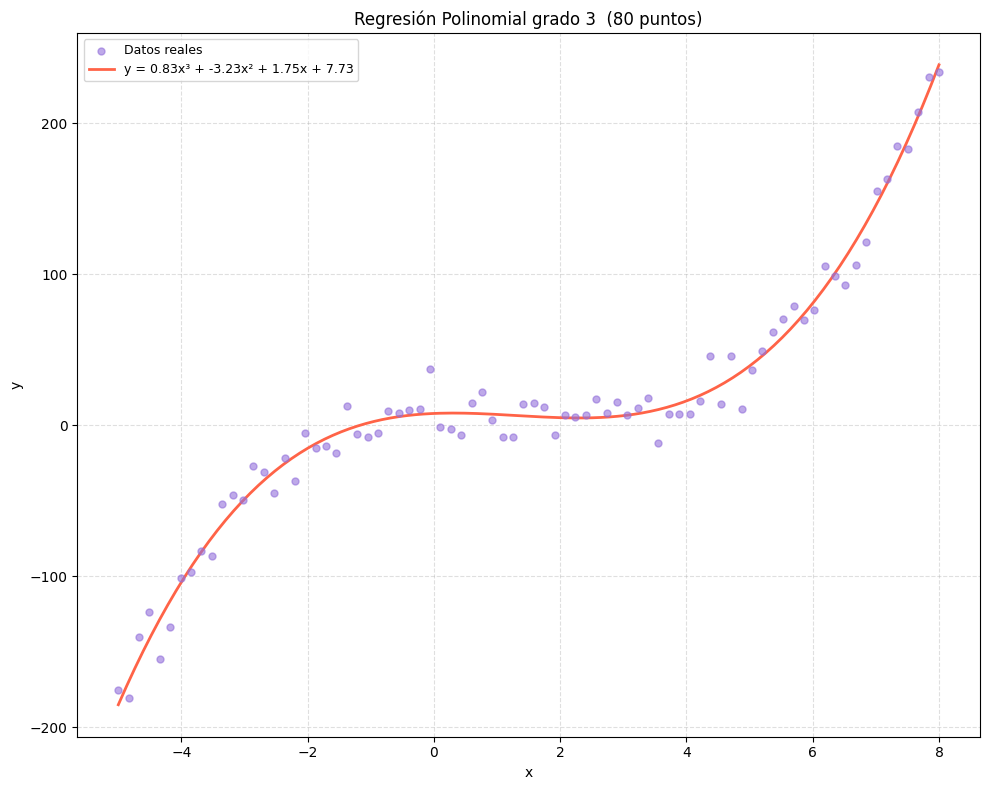

Real:      a3=0.80, a2=-3.00, a1=2.00, b=5.00
Calculado: a3=0.8271, a2=-3.2288, a1=1.7513, b=7.7259


In [18]:
# ══════════════════════════════════════════════════════
#  REGRESIÓN POLINOMIAL  —  y = 0.8x³ - 3x² + 2x + 5
# ══════════════════════════════════════════════════════
rng = np.random.default_rng(42)

x_pol = np.linspace(-5, 8, 80)
ruido_pol = rng.normal(loc=0, scale=15, size=80)
y_pol = 0.8*(x_pol**3) - 3*(x_pol**2) + 2*x_pol + 5 + ruido_pol

x_pol_lst = x_pol.tolist()
y_pol_lst = y_pol.tolist()

coefs = polinomial.regresion(x_pol_lst, y_pol_lst, grado=3)
c = coefs

x_curva = np.linspace(min(x_pol), max(x_pol), 200).tolist()
y_curva = [evaluar_pol(xi, c) for xi in x_curva]

plt.figure(figsize=(10, 8))
plt.scatter(x_pol, y_pol, color="mediumpurple", s=25, alpha=0.6, zorder=5, label="Datos reales")
plt.plot(x_curva, y_curva, color="tomato", linewidth=2,
         label=f"y = {c[3]:.2f}x³ + {c[2]:.2f}x² + {c[1]:.2f}x + {c[0]:.2f}")
plt.title("Regresión Polinomial grado 3  (80 puntos)", fontsize=12)
plt.xlabel("x")
plt.ylabel("y")
plt.legend(fontsize=9)
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

print(f"Real:      a3=0.80, a2=-3.00, a1=2.00, b=5.00")
print(f"Calculado: a3={c[3]:.4f}, a2={c[2]:.4f}, a1={c[1]:.4f}, b={c[0]:.4f}")